#**Álgebra Linear e Aplicações (SME0142) - Trabalho Final**
##Participantes:
Bruno Berndt Lima - 12542550\
José Pedro Cioni do Carmo - 12623988\
Thiago Shimada - 12691032

##Tema: Criptografia

#**O Conceito Criptografia**
É uma área da criptologia que estuda e pratica princípios e técnicas para comunicação segura na presença de terceiros. Mas geralmente, a criptografia refere-se à construção e análise de protocolos que impedem terceiros, ou o público, de lerem mensagens privadas. É uma técnica utilizada para cifrar dados, ou seja, torná-los incompreensíveis quando acessados por pessoas que não tenham a chave de acesso ou os meios próprios para decifrá-los.  Na linguagem da criptografia, os códigos são chamados de cifras (*cipher*), as mensagens não codificadas são chamadas de texto simples (*plaintext*) e as mensagens codificadas são chamadas de texto cifrado (*ciphertext*).

A cifra é um ou mais algoritmos que cifram e decifram um texto. A operação do algoritmo costuma ter como parâmetro uma chave criptográfica. Tal parâmetro costuma ser secreto (conhecido somente pelos comunicantes). A cifra pode ser conhecida, mas não a chave; assim como se entende o mecanismo de uma fechadura comum, mas não se pode abrir a porta sem uma chave real.

A criptografia tem sido por muito tempo uma questão importante no reino dos computadores. Foi usado principalmente para a segurança de senhas, mas agora a criptografia é muito importante devido ao fluxo de informações confidenciais da *Internet*, como informações de cartão de crédito, aplicativos de mensagem privada, como o *Whatsapp* e *Telegram*, que possuem criptografia de ponta a ponta, de forma que apenas a pessoa emissora e a pessoa receptora consigam entender as informações compartilhadas, *internet banking* em que essa técnica é utilizada para proteger e dificultar falhas nas transações recebidas e enviadas por aplicativos de banco, entre outras formas de uso.


#**Cifra de Hill**
A cifra de Hill (*Hill Cipher*) é uma cifra de substituição poligráfica baseada em álgebra linear, desenvolvida pelo matemático Lester S. Hill. Foi a primeira cifra poligráfica em que era prático operar em mais de três símbolos ao mesmo tempo.\
Ela usa a multiplicação de matrizes para transformar blocos de letras de texto simples em blocos de texto cifrado. Uma mensagem codificada com uma matriz $NxN$ é chamada de "N-Cifra de Hill". Logo, uma mensagem codificada com uma matriz $2x2$ é chamada "2-Cifra de Hill".
##Procedimento
Primeiro converte-se as letras em números:
\begin{array}{|c|c|} \hline
Letra&a&b&c&d&e&f&g&h&i&j&k&l&m&n&o&p&q&r&s&t&u&v&w&x&y&z \\ \hline
Número&0&1&2&3&4&5&6&7&8&9&10&11&12&13&14&15&16&17&18&19&20&21&22&23&24&25 \\ \hline
\end{array}

Depois agrupa-se os números $N$ a $N$ e multiplica-se cada grupo por uma matriz quadrada de ordem invertível (ou seja, determinante diferente de 0). Os números resultantes são novamente passados para letras, e assim tem-se a mensagem codificada.

Caso algum resultado da multiplicação seja um número maior que o número de letras do alfabeto utilizado, então deve-se utilizar o resto desse número pelo número de letras do alfabeto.

Para decodificar a mensagem basta aplicar o mesmo processo, porém utilizando a matriz inversa. Por isso que deve-se usar apenas matrizes invertíveis.

A matriz utilizada para criptografia é a chave cifrada, e deve ser escolhida aleatoriamente do conjunto de matrizes $N × N$ invertíveis (módulo 26). A cifra pode, é claro, ser adaptada a um alfabeto com qualquer número de letras, toda aritmética só precisa ser feita módulo o número de letras em vez de módulo 26.

## Exemplo para criptografar e descriptografar uma mensagem
Considere a seguinte mensagem:
```
universidade de sao paulo
```

Dividimos a mensagem em dígrafos:
```
un iv er si da de de sa op au lo
```
Se o tamanho da mensagem não consistisse em um número múltiplo do número de linhas da matriz de cifra, completaríamos a mensagem com qualquer caractere no final até que se tornasse múltiplo.

Agora convertemos cada par de letras em seu par de números equivalente.
```
  un  |  iv  |  er  |  si  |  da  |  de  |  de  |  sa  |  op   |  au  |  lo
20 13 | 8 21 | 4 17 | 18 8 | 3  0 | 3  4 | 3  4 | 18 0 | 14 15 | 0 20 | 11 14     
```
Criptografamos usando uma chave K, por exemplo:
$$
K = \left[
\begin{array}{cc}
2&3 \\
5&8 \\
\end{array}
\right]
$$

Transformamos o par de números em um vetor coluna, $[u,n] = [20,13]$ e
multiplicamos pela chave:

$$
\left[
\begin{array}{cc}
2&3 \\
5&8 \\
\end{array}
\right]
\left[
\begin{array}{c}
20 \\
13 \\
\end{array}
\right]
= \left[
\begin{array}{c}
79 \\
204 \\
\end{array}
\right]
$$

Precisamos que nosso resultado seja $mod 26$:
$$
\left[
\begin{array}{c}
79 \\
204 \\
\end{array}
\right]
= \left[
\begin{array}{c}
1 \\
22 \\
\end{array}
\right]mod26
$$

Fazendo isso para cada par, obtemos:
```
Mensagem:     un  |  iv  |  er  |  si  |  da  |  de   |  de   |  sa   |  op   |  au  |  lo
Convertida: 20 13 | 8 21 | 4 17 | 18 8 | 3  0 | 3  4  | 3  4  | 18 0  | 14 15 | 0 20 | 11 14
Cifrada:     1 22 | 1  0 | 7  0 | 8 24 | 6 15 | 18 21 | 18 21 | 10 12 | 21  8 | 8  4 | 12 11 

```  
```
Mensagem criptografada: bwbahaiygpsvsvkmviieml
```  

Agora vamos descriptografar a mensagem que foi criptografada, para isso precisamos encontrar a matriz inversa de $K$:

$$
\left[
\begin{array}{cc}
2&3 \\
5&8 \\
\end{array}
\right]^{-1}=
\left[
\begin{array}{cc}
8&-3 \\
-5&2 \\
\end{array}
\right]=
\left[
\begin{array}{cc}
8&23 \\
21&2 \\
\end{array}
\right]mod26
$$

Então, basta multiplicar o par de número que foi encontrado aplicando a cifra pela matriz inversa:

$$
\left[
\begin{array}{cc}
8&23 \\
21&2 \\
\end{array}
\right]
\left[
\begin{array}{c}
1 \\
22 \\
\end{array}
\right]
= \left[
\begin{array}{c}
514 \\
65 \\
\end{array}
\right]=
\left[
\begin{array}{cc}
20 \\
13 \\
\end{array}
\right]mod26
$$

E fazendo isso para cada par, obtemos a mensagem inicial novamente:
```
un iv er si da de de sa op au lo = universidade de sao paulo

```


## Segurança
Pode ser difícil criptoanalisar uma cifra de Hill usando um ataque somente de texto cifrado, mas é fácil quebrar usando um ataque de texto simples conhecido. Um ataque de texto simples conhecido significa que conhecemos um pouco do texto cifrado e o texto simples correspondente – um berço. Esta não é uma situação incomum. Frequentemente, as mensagens têm começos estereotipados (por exemplo, para, olá) ou terminações estereotipadas (por exemplo, beijos, atenciosamente) ou às vezes é possível (conhecer o remetente e destinatário ou saber qual é o provável conteúdo do mensagem) para adivinhar uma parte de uma mensagem.

Um ataque de texto simples conhecido funciona bem contra uma cifra de Hill porque há uma relação algébrica entre texto simples e texto cifrado (como existe para cifras de César, cifras multiplicativas e cifras afins) e a
relação é linear. Um terceiro que intercepta $n^2$ pares de caracteres de texto simples/texto cifrado pode configurar um sistema linear que pode (geralmente) ser facilmente resolvido, se acontecer que este sistema seja indeterminado, basta adicionar mais alguns pares de texto simples/texto cifrado. Calcular essa solução por algoritmos de álgebra linear padrão leva muito pouco tempo.

Embora a multiplicação de matrizes sozinha não resulte em uma cifra segura, ainda é uma etapa útil quando combinada com outras operações não lineares, porque a multiplicação de matrizes pode fornecer difusão. Por exemplo, uma matriz escolhida apropriadamente pode garantir que pequenas diferenças antes da multiplicação da matriz resultarão em grandes diferenças após a multiplicação da matriz.



##Implementação da Cifra de Hill para criptografia de texto

In [ ]:
# Bibliotecas utilizadas para fazer manipulações em matrizes 
from sympy import *
import numpy as np
import random


In [ ]:
# salva todos os caracteres para que possam ser representados em números
characters = "zabcdefghijklmnopqrstuvwxyZABCDEFGHIJKLMNOPQRSTUVWXY0123456789?!@#$%^&*-+=()[]{}\|/<>.,:;_\"'`~ "

# dicionário que irá guardar cada par <número correspondente : caractere)>
dictionary = {}
# dicionário que irá guardar cada par <caractere : número correspondente)>
inv_dictionary = {}

# salva nos dicionários os valores
for i in range(0, len(characters)):
  inv_dictionary[characters[i]] = i
  dictionary[i] = characters[i]

print_dictionary(dictionary)


Número:    0  1  2  3  4  5  6  7  8  9  10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 
Caractere: z  a  b  c  d  e  f  g  h  i  j  k  l  m  n  o  p  q  r  s  t  u  v  w  x  y  Z  A  B  C  D  E  F  G  H  I  J  K  L  M  N  O  P  Q  R  S  T  U  V  W  X  Y  0  1  2  3  4  5  6  7  8  9  ?  !  @  #  $  %  ^  &  *  -  +  =  (  )  [  ]  {  }  \  |  /  <  >  .  ,  :  ;  _  "  '  `  ~     

In [ ]:
# hill_cipher: função que aplica a cifra de hill a uma mensagem
# Parâmetros:
#   @string: texto que se deseja criptografar ou descriptografar
#   @cipher: matriz que será usada como chave(cipher)
def hill_cipher(string, cipher):
  text = string
  transformed_text = '' # texto gerado após aplicação da cifra
  
  # para i de 0 até o tamanho da mensagem, vai incrementando de acordo com o número de dígrafos escolhido
  for i in range(0,len(text), cipher.shape[0]):
    # vetor auxiliar que irá guardar o número da letra correspondente encriptada
    aux = []
    # para j de i até i + número de dígrafos escolhido
    for j in range(i, i + cipher.shape[0]):
      # adiciona no final de aux o número correspondente ao caractere j da mensagem
      aux.append(inv_dictionary[text[j]])
    
    aux = np.array(aux)
    # aplica a cifra 
    aux = (cipher @ aux) % len(characters)
  
    # para cada valor encriptado em aux, encontra o caractere correspondente
    for j in aux:
      transformed_text += dictionary[j]

  # retorna o texto cifrado e count
  return transformed_text

In [ ]:
# encrypt(): função que encripta a mensagem desejada usando a cifra de Hill
# Parâmetros:
#   @message: texto simples(plain_text) que se deseja criptografar
#   @cipher: matriz que será usada como chave(cipher) para criptografar
def encrypt(message, cipher):
  # completa o texto se necessário
  message, count = complete_text(message, cipher)

  # aplica a cifra de Hill para criptografar o texto
  encrypted_msg = hill_cipher(message, cipher)

  return encrypted_msg, count

In [ ]:
# decrypt(): função que decripta a mensagem desejada usando a cifra de Hill
# Parâmetros:
#   @string: texto cifrado(cipher_text) que se deseja descriptografar
#   @inv_cipher: matriz inversa da chave(cipher) para descriptografar
#   @count: contador de caracteres adicionado no texto na função encrypt()
def decrypt(string, inv_cipher, count):
  # aplica a cifra de Hill para descriptografar o texto
  decrypted_msg = hill_cipher(string, inv_cipher)

  # remove caracteres caso tenham sido adicionados
  msg = remove_added_chars(decrypted_msg, count)

  return msg

In [ ]:
# Funções auxiliares

# função para imprimir o dicionário de caracteres
def print_dictionary(dictionary):
  print('Número:    ', end="")
  for number in dictionary.keys():
    print("{:<3}".format(number), end= "")
  print('\nCaractere: ', end="")
  for character in dictionary.values():
    print("{:<3}".format(character), end= "")

# função que completa o texto se necessário para que o temanho do texto 
# seja múltiplo da quantidade de linhas da matriz cipher
def complete_text(text, cipher):
  count = 0 # contador para a quantidade de caractere adicionado em plain_text
  while len(text) % cipher.shape[0] != 0:
    text += 's' # deixando o array de palavras múltiplo das linha da matriz
    count += 1
  return text, count

# função que remove caracteres, caso tenham sido adicionados pela função complete_text()
def remove_added_chars(text, count):
  for index in range(len(text)-count, len(text)):
    if len(text) > index:
      text = text[0 : index : ] + text[len(text) : : ]
  return text

def generate_random_nums(n):
  random_numbers = []
  for i in range(0, n):
    n = random.randint(1,30)
    random_numbers.append(n)
  return random_numbers

## Casos de Teste

In [ ]:
# matriz 2x2

mensagem = "Universidade de Sao Paulo, 2022!"

while (True):
  cifra = Matrix(2, 2, generate_random_nums(4))
  try:
    cifra_inv = cifra.inv_mod(len(characters))
    break
  except:
    pass

msg_criptografada, count = encrypt(mensagem, cifra)
 
msg_descriptografada = decrypt(msg_criptografada, cifra_inv, count)

print('Mensagem criptografada: {}'.format(msg_criptografada))
print('Mensagem descriptografada: {}'.format(msg_descriptografada))


Mensagem criptografada: ?y%ff`Ts"U<B-&!pAWQ,-BY"5CE&]8x3
Mensagem descriptografada: Universidade de Sao Paulo, 2022!


In [ ]:
# matriz 3x3

mensagem = "F(x) = 3x + 5"

while (True):
  cifra = Matrix(3, 3, generate_random_nums(9))
  try:
    cifra_inv = cifra.inv_mod(len(characters))
    break
  except:
    pass

msg_criptografada, count = encrypt(mensagem, cifra)

msg_descriptografada = decrypt(msg_criptografada, cifra_inv, count)

print('Mensagem criptografada: {}'.format(msg_criptografada))
print('Mensagem descriptografada: {}'.format(msg_descriptografada))


Mensagem criptografada: dtE"]$b! nj>sz[
Mensagem descriptografada: F(x) = 3x + 5


In [ ]:
# matriz 4x4

mensagem = "Lorem ipsum dolor sit amet, consectetur adipiscing elit. Proin feugiat, erat id porta ultricies, neque odio fermentum nunc, id commodo velit ligula sed nulla."

while (True):
  cifra = Matrix(4, 4, generate_random_nums(16))
  try:
    cifra_inv = cifra.inv_mod(len(characters))
    break
  except:
    pass


msg_criptografada, count = encrypt(mensagem, cifra)
cifra_inv = cifra.inv_mod(len(characters)) 
msg_descriptografada = decrypt(msg_criptografada, cifra_inv, count)

print('Mensagem criptografada: {}'.format(msg_criptografada))
print('Mensagem descriptografada: {}'.format(msg_descriptografada))

Mensagem criptografada: `s!WXYb56D.R/I jg*q3O<x*<{.#y/1M>O6:#?-J|0\;U$hf:,EtEAfXz#T>K!1nhp$Xo#[KTF^V>l;`6)OeCUD$MRQ(*Si~c`BY8uE--!=r*(k{a4>0"Y/US058Xxr$N_<z@1x n^:5j04bps!tA@WZVG.fOwfe
Mensagem descriptografada: Lorem ipsum dolor sit amet, consectetur adipiscing elit. Proin feugiat, erat id porta ultricies, neque odio fermentum nunc, id commodo velit ligula sed nulla.


##Implementação da Cifra de Hill para criptografia de imagem


In [ ]:
from PIL import Image, ImageOps


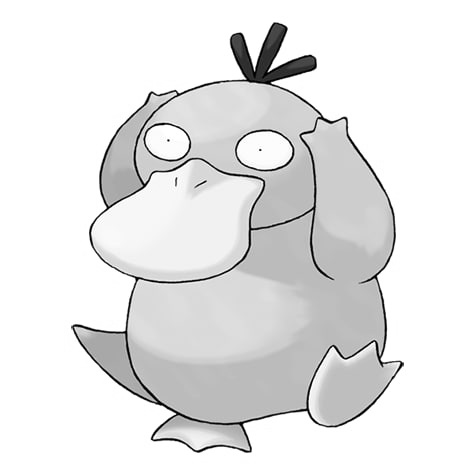

In [ ]:
# Imagem a ser criptografada
img = np.array(Image.open('/content/sample_data/psyduck.png').convert('L'))
display(Image.fromarray(img))


In [ ]:
# função que completa a imagem se necessário para que o tamanho da imagem 
# seja múltiplo da quantidade de linhas da matriz cipher
def complete_img(img, cipher):
  count = 0 # contador para a quantidade de pixel adicionado em plain_text
  z = np.zeros((1,img.shape[1]))
  while img.shape[0] % cipher.shape[0] != 0:
    img = np.append(img, z, axis=0) # deixando o array de palavras múltiplo das linha da matriz
    count += 1
  return img, count

# função que remove pixels, caso tenham sido adicionados pela função complete_image()
def remove_added_pixels(img, count):
  for i in range(count):
    img = np.delete(img, img.shape[0] - 1, 0)
    pass
  return img

# hill_cipher_img: função que aplica a cifra de hill a uma imagem
# Parâmetros:
#   @img: imagem que se deseja criptografar ou descriptografar
#   @cipher: matriz que será usada como chave(cipher)
def hill_cipher_img(img, cipher):
  transformed_img = img.copy() # imagem gerada após aplicação da cifra

  # implementa o algoritmo da cifra de hill
  for t in range(0,img.shape[0], cipher.shape[0]):
    aux = img[t:t+cipher.shape[0],:]
    aux = (cipher @ aux) % 256
    transformed_img[t:t+cipher.shape[0],:] = aux
    
  return transformed_img

# encrypt_img(): função que encripta a mensagem desejada usando a cifra de Hill
# Parâmetros:
#   @img: imagem que se deseja criptografar
#   @cipher: matriz que será usada como chave(cipher) para criptografar
def encrypt_img(img, cipher):
  # completa a imagem se necessário
  img, count = complete_img(img, cipher)

  # aplica a cifra de Hill para criptografar o texto
  encrypted_img = hill_cipher_img(img, cipher)

  return encrypted_img, count

# decrypt_img(): função que decripta a imagem desejada usando a cifra de Hill
# Parâmetros:
#   @img: imagem que se deseja descriptografar
#   @inv_cipher: matriz inversa da chave(cipher) para descriptografar
#   @count: contador de pixel adicionado no texto na função encrypt()
def decrypt_img(img, inv_cipher, count):
  # aplica a cifra de Hill para descriptografar o texto
  decrypted_img = hill_cipher_img(img, inv_cipher)

  # remove caracteres caso tenham sido adicionados
  decrypted_img = remove_added_pixels(decrypted_img, count)

  return decrypted_img



## Caso de Teste

In [ ]:
while True:
  cifra = Matrix(3, 3, generate_random_nums(9))
  try:
    cifra_inv = cifra.inv_mod(256) 
    break 
  except:
    pass

img_criptografada, count = encrypt_img(img, cifra)

img_descriptografada = decrypt_img(img_criptografada, cifra_inv, count)

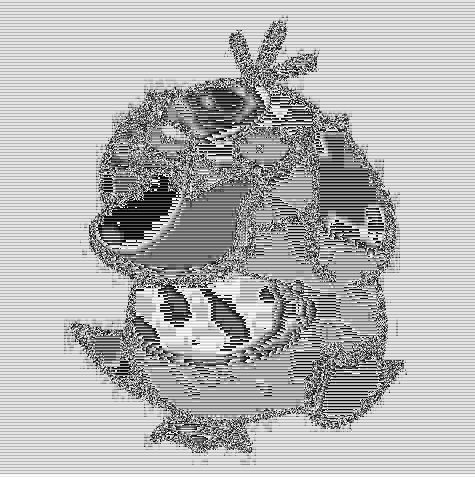

In [ ]:
img_criptografada = Image.fromarray(img_criptografada).convert("L")

display(img_criptografada)


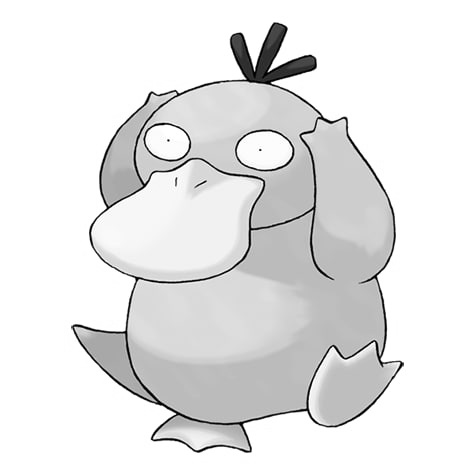

In [ ]:
img_descriptografada = Image.fromarray(img_descriptografada).convert("L")

display(img_descriptografada)


## Considerações
Como foi mostrado, a Cifra de Hill não é muito segura, por existir uma relação linear entre o texto simples e o texto cifrado. Visulizando a imagem criptografada é nítido perceber algumas formas e padrões existentes na imagem original. Para fazermos um comparativo, iremos explicar brevemente sobre a AES, um outro algoritmo de codificação em que não é possível para humanos ou máquinas entenderem sem uma chave de criptografia - uma senha, e utilizar essa criptografia na mesma imagem em que foi aplicada a Cifra de Hill. 


#**Cifra AES**

A cifra AES (Advanced Encryption Standard - padrão de criptografia avançada) é uma cifra simétrica, ou seja, a mesma chave é usada para criptografar e descriptografar os dados, baseada no princípio conhecido como rede de substituição e permutação, sendo utilizada como o padrão de criptografia por sua eficiência em software e hardware. É uma variação da cifra de bloco de Rijndael desenvolvida pelos criptólogos Joan Daemen e Vincent Rijmen. Por ser uma cifra de bloco, a criptografia é feita em tamanhos fixos de 128 bits, utilizando uma chave que pode possuir 128, 192 ou 256 bits. Grande parte dos cálculos da AES são realizadas em um campo finito.

Para a criptografia AES, é utilizada uma matriz 4x4, conhecida como estado, onde os bytes $b0, b1,...,b15$ são representados da seguinte forma:

$$
\left[
\begin{array}{cc}
b_{0} & b_{4} & b_{8} & b_{12} \\
b_{1} & b_{5} & b_{9} & b_{13} \\
b_{2} & b_{6} & b_{10} & b_{14} \\
b_{3} & b_{7} & b_{11} & b_{15}
\end{array}
\right]
$$

O tamanho da chave define a quantidade de rodadas de transformações sobre a entrada, chamada de texto simples, para a saída, chamada de texto cifrado. O número de rodadas segue:
* 10 rodadas para chaves de 128-bits
* 12 rodadas para chaves de 196-bits
* 14 rodadas para chaves de 256-bits

Cada rodada consiste de passos que podem ou não depender da chave criptográfica. Todos passos são reversíveis, então um conjunto de rodadas reversas é aplicado ao texto cifrado para retornar ao texto original utilizando a mesma chave.

##Descrição do algoritmo
1. KeyExpansion - as chaves de 128-bits de cada rodada são derivadas da chave inicial através do processo conhecido como AES Key Scheduling, que utiliza as operações de multiplicação e de $\oplus$ (XOR) para calcular as novas chaves.
1. Adição da chave da rodada: 
  1. AddRoundKey - cada byte do estado é combinado com um byte da chave da rodada utilizando a operação XOR
1. n-1 rodadas:
  1. SubBytes - uma etapa de substituição não linear, onde cada byte é substituido de acordo com uma [tabela de pesquisa](https://en.wikipedia.org/wiki/Rijndael_S-box)
  1. ShiftRows - uma etapa de transposição em que as três últimas linhas do estado são deslocadas ciclicamente em um certo número de etapas.
  1. MixColumns  – uma operação de mistura linear que opera nas colunas do estado, combinando os quatro bytes em cada coluna.
  1. AddRoundKey
1. Última rodada:
  1. SubBytes
  1. ShiftRows
  1. AddRoundKey

##Etapa SubBytes

A transformação SubBytes substitui cada byte $a_{ij}$ do estado por um SubByte $S(a_{ij})$, de acordo com uma tabela de substituição, conhecida como S-Box. Essa tabela é montada utilizando o inverso multiplicativo de cada elemento e em seguida aplicando-se a transformação:

\begin{align}
        a_{i} = b_{i} ⊕ b_{i+4} ⊕ b_{i+5} ⊕ b_{i+6} ⊕ b_{i+7} ⊕ c_{i}
    \end{align}
onde $i$ é o índice de cada bit pertencente a um byte ($0 \leq i \leq 8$), $B=b_{7}b_{6}b_{5}b_{4}b_{3}b_{2}b_{1}b_{0}$ é o byte de entrada, $A=a_{7}a_{6}a_{5}a_{4}a_{3}a_{2}a_{1}a_{0}$ é o byte de saída da operação e $C$ é um byte constante de valor $63h$, ou $01100011$. Esta transformação também pode ser representada da forma matricial:

$$
\left[
\begin{array}{cc}
a_{0}\\
a_{1}\\
a_{2}\\
a_{3}\\
a_{4}\\
a_{5}\\
a_{6}\\
a_{7}\\
\end{array}
\right]=
\left[
\begin{array}{cc}
1 & 0 & 0 & 0 & 1 & 1 & 1 & 1\\
1 & 1 & 0 & 0 & 0 & 1 & 1 & 1\\
1 & 1 & 1 & 0 & 0 & 0 & 1 & 1\\
1 & 1 & 1 & 1 & 0 & 0 & 0 & 1\\
1 & 1 & 1 & 1 & 1 & 0 & 0 & 0\\
0 & 1 & 1 & 1 & 1 & 1 & 0 & 0\\
0 & 0 & 1 & 1 & 1 & 1 & 1 & 0\\
0 & 0 & 0 & 1 & 1 & 1 & 1 & 1\\
\end{array}
\right]
\left[
\begin{array}{cc}
b_{0}\\
b_{1}\\
b_{2}\\
b_{3}\\
b_{4}\\
b_{5}\\
b_{6}\\
b_{7}\\
\end{array}
\right] +
\left[
\begin{array}{cc}
1\\
1\\
0\\
0\\
0\\
1\\
1\\
0\\
\end{array}
\right]  
$$

##Etapa ShiftRows

Nessa etapa os bytes de cada linha são trocados, de acordo com uma rotação para a esquerda, que depende do número da linha. Considerando $n$ como o número da linha, $0 \leq n \leq 3$, sendo $n$ também o offset de cada linha $n$. Essa etapa é importante para evitar que as colunas sejam criptografadas independentemente. A transformação dessa etapa pode ser visualizada abaixo:

$$
\left[
\begin{array}{cc}
B_{00} & B_{01} & B_{02} & B_{03}\\
B_{10} & B_{11} & B_{12} & B_{13}\\
B_{20} & B_{21} & B_{22} & B_{23}\\
B_{30} & B_{31} & B_{32} & B_{33}\\ 
\end{array}
\right] →
\left[
\begin{array}{cc}
B_{00} & B_{01} & B_{02} & B_{03}\\
B_{11} & B_{12} & B_{13} & B_{10}\\
B_{22} & B_{23} & B_{20} & B_{21}\\
B_{33} & B_{30} & B_{31} & B_{32}\\ 
\end{array}
\right]
$$

##Etapa MixColumns

Nesta etapa, os quatro bytes de cada coluna são combinados utilizando uma transformação linear invertível. Juntamente da etapa ShiftRows, o passo MixColumns causa a difusão da cifra.

Durante esta operação, cada coluna da matriz estado é multiplicada por uma matriz fixa. A operação é mostrada abaixo:

$$
\left[
\begin{array}{cc}
b_{0j}\\
b_{1j}\\
b_{2j}\\
b_{3j}\\ 
\end{array}
\right] =
\left[
\begin{array}{cc}
2 & 3 & 1 & 1\\
1 & 2 & 3 & 1\\
1 & 1 & 2 & 3\\
3 & 1 & 1 & 2\\ 
\end{array}
\right]
\left[
\begin{array}{cc}
a_{0j}\\
a_{1j}\\
a_{2j}\\
a_{3j}\\ 
\end{array}
\right]
\hspace{2em} 0 \leq j \leq 3
$$

##Etapa AddRoundKey

Nesta etapa, a subchave é combinada com o estado. Para cada rodada, uma nova subchave é derivada da chave principal utilizando o AES Key Scheduling. Cada subchave tem o mesmo tamanho que o estado (128-bits). A subchave é combinada ao estado utilizando operador bitwise $\oplus$ (XOR).

##Segurança

A chave AES é o elo mais fraco da cadeia, é preciso protegê-la a todo custo!

Sem entrar em detalhes técnicos, a função matemática garante a força da criptografia, e é por isso que o AES é considerado inquebrável, desde que as propriedades da função sejam respeitadas - chave forte, cifra corretamente implementada, vetor de inicialização único, etc. 

Embora não demorasse literalmente uma eternidade, levaria muito mais tempo do que qualquer uma de nossas vidas para quebrar uma chave de criptografia AES de 256 bits usando a tecnologia de computação moderna, do ponto de vista da força bruta.

Em junho de 2003, o governo dos Estados Unidos anunciou que o AES poderia ser utilizado para proteger informações confidenciais:

> "The design and strength of all key lengths of the AES algorithm (i.e., 128, 192 and 256) are sufficient to protect classified information up to the SECRET level. TOP SECRET information will require use of either the 192 or 256 key lengths. The implementation of AES in products intended to protect national security systems and/or information must be reviewed and certified by NSA prior to their acquisition and use"

Até o presente momento, não são conhecidos ataques práticos que permitem alguém que não possua a chave principal a ler os dados criptografados.

## Implementação da AES para criptografia de imagem


In [ ]:
!pip install pycryptodome

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 2.3 MB 26.0 MB/s 


In [ ]:
from PIL import Image 
# Biblioteca que implementa a criptografia AES
from Crypto.Cipher import AES  

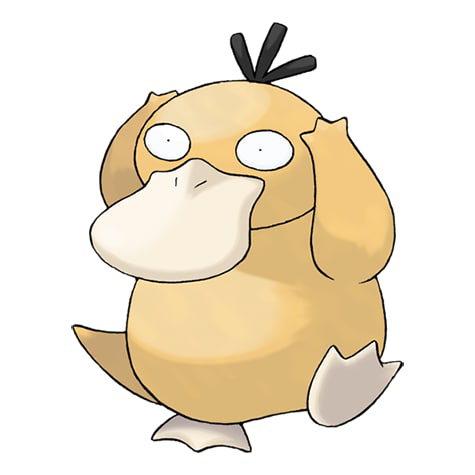

In [ ]:
# Imagem original a ser criptografada
filename = "psyduck.png" 

im = Image.open(filename) 
display(im)

In [ ]:
# chave de criptografia
key = "abcdefghijklmnop" 
 
# AES requer que os textos simples sejam múltiplos de 16, então temos que preencher os dados
def pad(data): 
    return data + b"\x00"*(16-len(data)%16)  
 
# converte para RGB para garantir que não tenha perca de informação 
def convert_to_RGB(data): 
    r, g, b = tuple(map(lambda d: [data[i] for i in range(0,len(data)) if i % 3 == d], [0, 1, 2])) 
    pixels = tuple(zip(r,g,b)) 
    return pixels 
     
def process_image(filename, mode): 
    # abre a imagem e a converte para o formato RGB para utilizar a biblioteca PIL 
    im = Image.open(filename) 
    data = im.convert("RGB").tobytes()  
 
    # Como preencheremos os dados para atender ao requisito de múltiplo de 16 do AES,
    # armazenaremos o comprimento original dos dados e "descompactaremos" mais tarde. 
    original = len(data)  
 
    if(mode == "encrypt"):  
      # encripta a imagem 
      new = convert_to_RGB(aes_encrypt(key, pad(data))[:original])  
    elif(mode == "decrypt"):
      # decripta a imagem
      new = convert_to_RGB(aes_decrypt(key, pad(data))[:original])
        
    # Crie um novo objeto de imagem PIL e salva os dados da imagem antiga na nova imagem.
    im2 = Image.new(im.mode, im.size) 
    im2.putdata(new) 
     
    # Salva a imagem 
    if(mode == "encrypt"):  
        im2.save(filename1) 
    elif(mode == "decrypt"):
        im2.save(filename2) 
 
def aes_encrypt(key, data, mode=AES.MODE_CBC): 
    IV = "A"*16   
    aes = AES.new(key.encode('utf8'), mode, IV.encode('utf8')) 
    new_data = aes.encrypt(data) 
    return new_data 

def aes_decrypt(key, data, mode=AES.MODE_CBC):
    IV = "A"*16  
    aes = AES.new(key.encode('utf8'), mode, IV.encode('utf8')) 
    new_data = aes.decrypt(data) 
    return new_data


## Caso de Teste

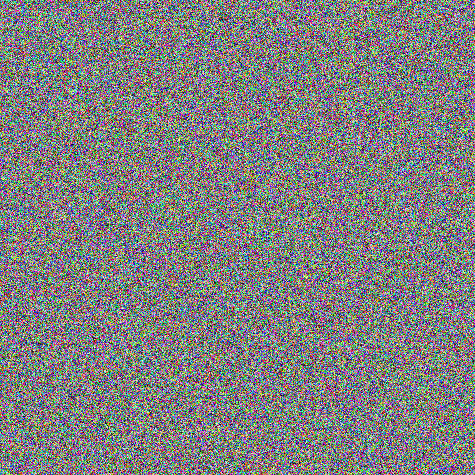

In [ ]:
# Imagem criptografada
filename1 = "img_criptografada.png"

process_image(filename, "encrypt") 

im = Image.open(filename1) 
display(im)


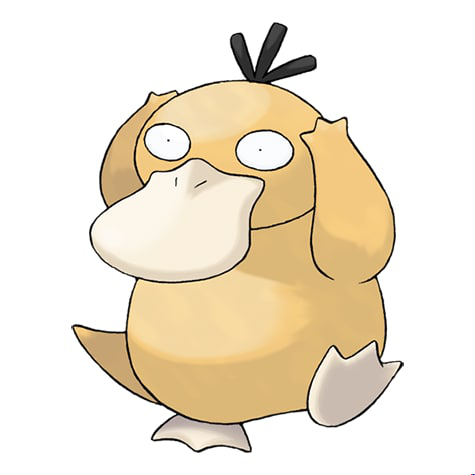

In [ ]:
# Imagem descriptografada
filename2 = "img_descriptografada.png"

process_image(filename1, "decrypt") 

im = Image.open(filename2) 
display(im)

# Considerações finais
O foco desse trabalho era apresentar a cifra de Hill que utiliza conceitos da álgebra linear. Para termos um comparativo falamos um pouco da cifra AES, que também utliza conceitos da álgebra como matrizes e transformações linaeres, e percebemos, comparando as imagens criptografadas por Hill e AES e pelo método utilizado por cada uma, que a AES é muito mais poderosa que a cifra de Hill, tanto em questão de segurança como em performance, e por conta disso se torna mais prático o uso em escala em aplicações da vida real.

A National Security Agency (NSA), bem como outros órgãos governamentais, utilizam criptografia AES e chaves para proteger informações classificadas ou outras informações confidenciais. Além disso, o AES é frequentemente incluído em produtos de base comercial, como:

* Wi-Fi (pode ser usado como parte do WPA2)
* Aplicativos móveis (como WhatsApp e LastPass)
* Suporte a processador nativo
* Bibliotecas em muitas linguagens de desenvolvimento de software
* Implementações VPN
* Componentes do sistema operacional, como sistemas de arquivos

#Referências Bibliográficas
https://pt.wikipedia.org/wiki/Criptografia

https://pt.wikipedia.org/wiki/Cifra_de_Hill

https://uomustansiriyah.edu.iq/media/lectures/5/5_2021_06_12!05_37_37_PM.pdf

https://pt.wikipedia.org/wiki/Advanced_Encryption_Standard

https://cryptoid.com.br/criptografia/aes-padrao-de-criptografia-avancado-o-que-e-e-como-funciona/